In [1]:
from rembg import remove

from PIL import Image

from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

TEST_DIR = BASE_DIR / "test_images"

OUTPUT_DIR = BASE_DIR / "outputs" / "background_removed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: D:\Git\eshani-2026\e_wardrobe_ai\outputs\background_removed


In [3]:
def remove_background(input_path, output_path):

    input_image = Image.open(input_path).convert("RGBA")

    output_image = remove(input_image)

    output_image.save(output_path)

    return output_image

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

Saved to: D:\Git\eshani-2026\e_wardrobe_ai\outputs\background_removed\shirt_no_bg.png


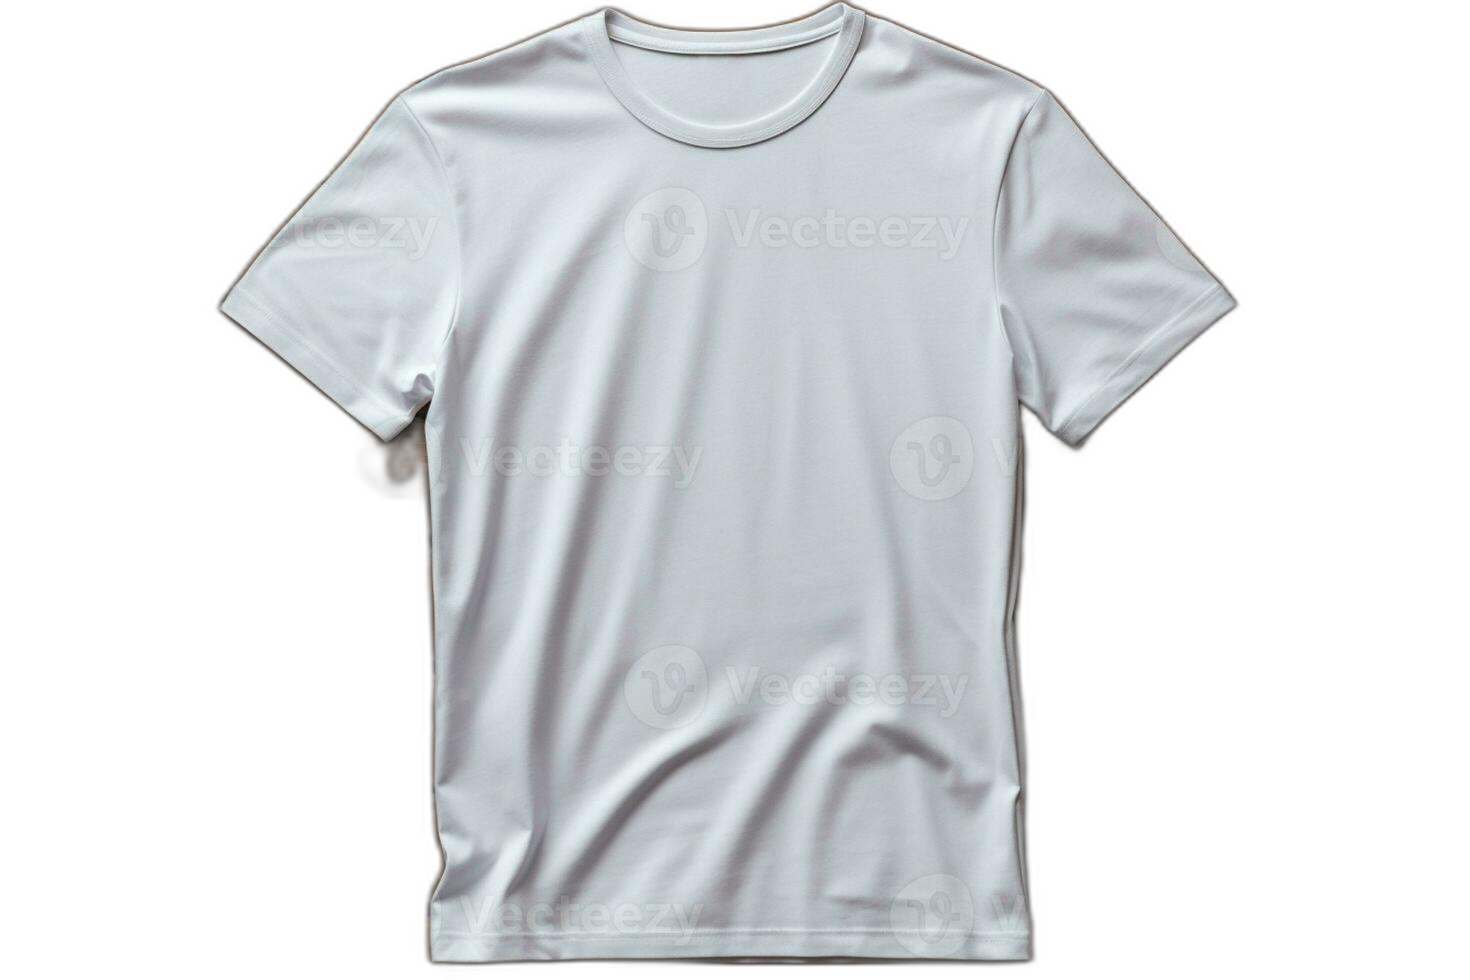

In [5]:
input_image = TEST_DIR / "aaaa.jpg"

output_image = OUTPUT_DIR / "shirt_no_bg.png"

result = remove_background(
    input_image,
    output_image
)

print("Saved to:", output_image)

result

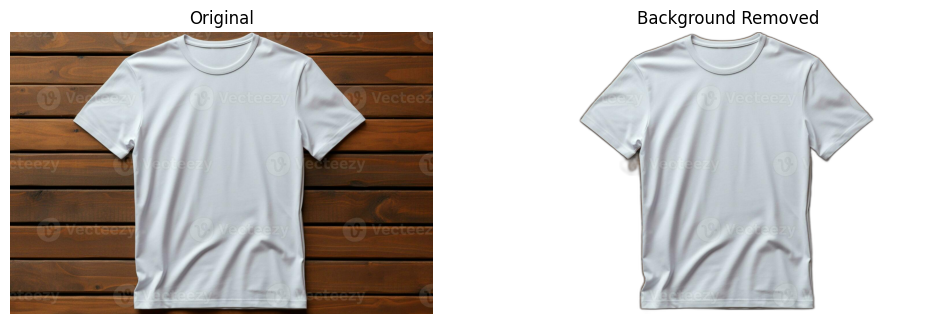

In [6]:
original = Image.open(input_image)
removed = Image.open(output_image)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(removed)
plt.title("Background Removed")
plt.axis("off")

plt.show()

In [7]:
import json
import torch
import torch.nn as nn

from torchvision import transforms, models

In [8]:
MODEL_DIR = BASE_DIR / "models"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(MODEL_DIR / "articleType_class_to_idx.json", "r") as f:
    class_to_idx = json.load(f)

idx_to_class = {
    int(v): k
    for k, v in class_to_idx.items()
}

num_classes = len(class_to_idx)

model = models.mobilenet_v2(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model.load_state_dict(
    torch.load(
        MODEL_DIR / "mobilenetv2_articleType_best.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Model loaded.")

Model loaded.


C:\Users\chathudu sahassara\AppData\Local\Temp\ipykernel_10884\3025986737.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [9]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
def classify_with_background_removal(image_path):

    # Remove background
    input_image = Image.open(image_path).convert("RGBA")

    bg_removed = remove(input_image)

    # Convert for CNN
    rgb_image = bg_removed.convert("RGB")

    input_tensor = transform(rgb_image).unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, prediction = torch.max(probabilities, 1)

    predicted_class = idx_to_class[prediction.item()]

    return rgb_image, predicted_class, confidence.item()

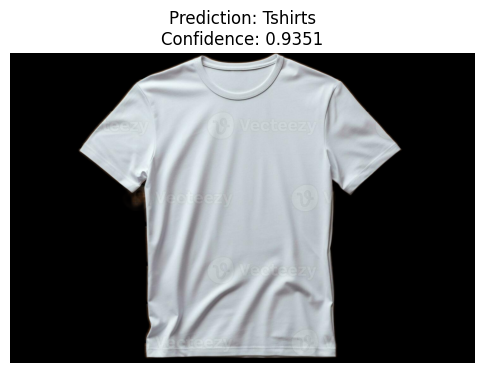

Predicted Class: Tshirts
Confidence: 0.9350666403770447


In [12]:
test_image = TEST_DIR / "aaaa.jpg"

image, predicted_class, confidence = classify_with_background_removal(test_image)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.4f}"
)

plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)